# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)



*(Your answer)*

- Figure is your canvas 
- axes is there plots live (drawings)




**2.** Name the three figure-level functions in `seaborn`.



*(Your answer)*


- displot
- catplot 
- relplot



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


A_3 Answer:

**Histogram** bins numerical data into ranges and shows the frequency of those ranges

**Barplot** each bar represents a category and the bar height represents some summary statistics



## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

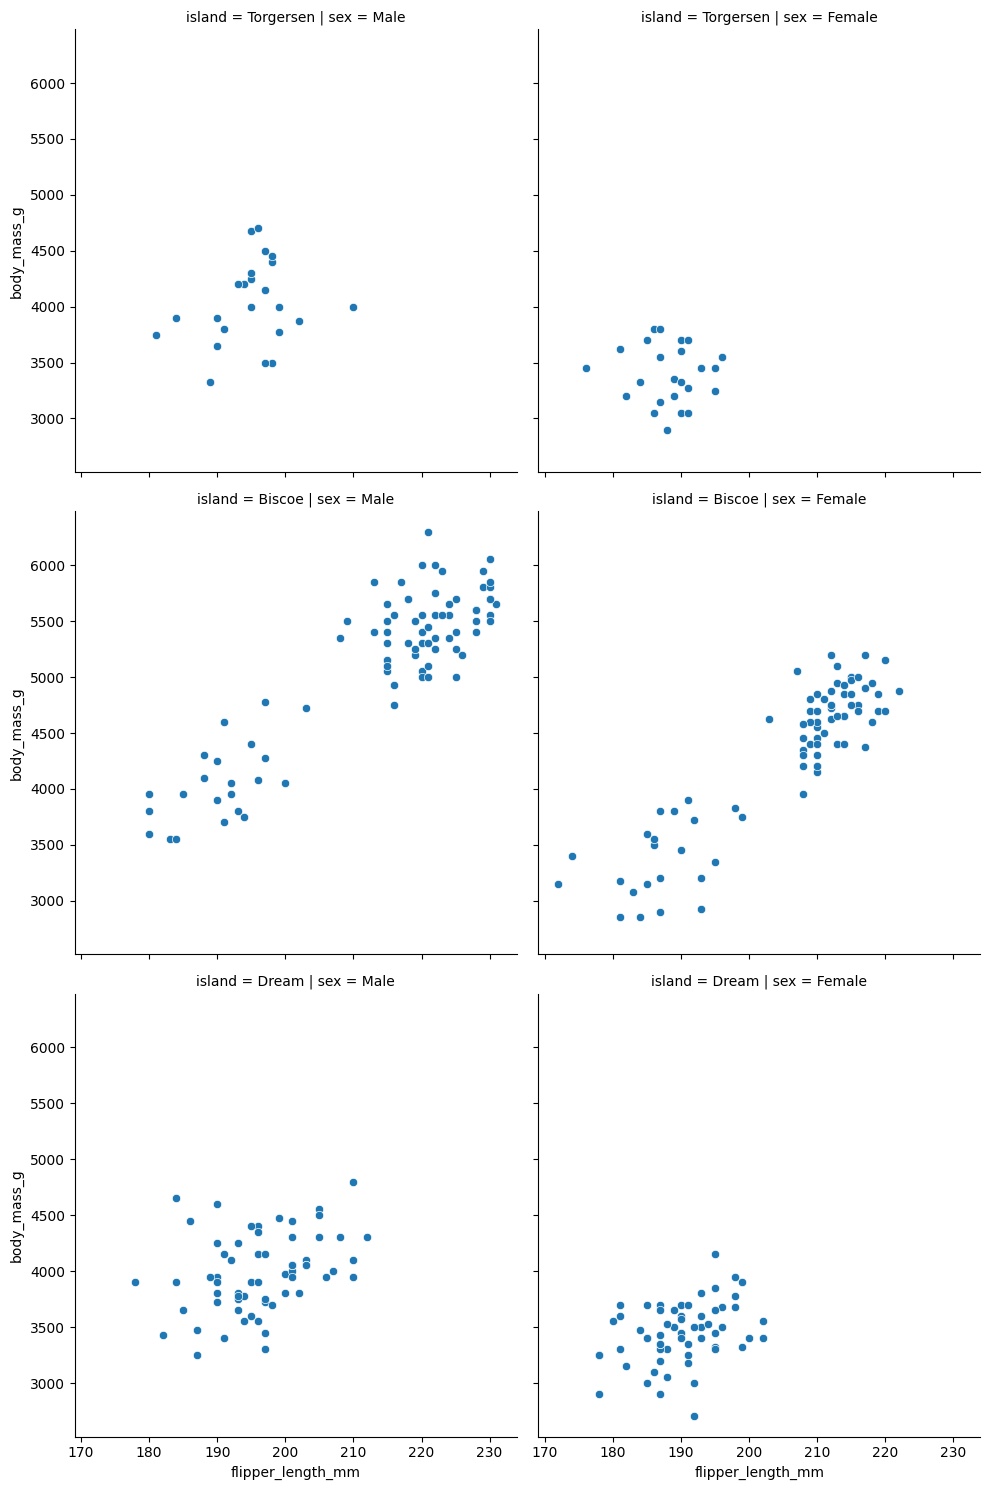

In [3]:
# YOUR CODE
sns.relplot(data=df,x='flipper_length_mm',y='body_mass_g',col='sex',row='island')

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

<Axes: xlabel='species', ylabel='bill_length_mm'>

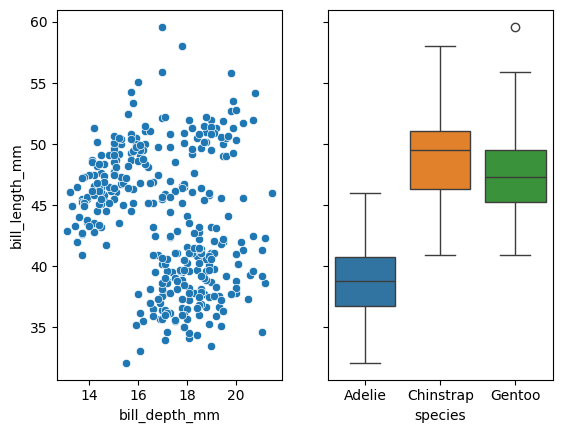

In [30]:
# YOUR CODE
fig, (ax1,ax2) = plt.subplots(1,2,sharey=True)
sns.scatterplot(data=df,x='bill_depth_mm',y='bill_length_mm',ax=ax1)
sns.boxplot(data=df,x='species',y='bill_length_mm',hue='species',ax = ax2)

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

<Axes: xlabel='species', ylabel='flipper_length_mm'>

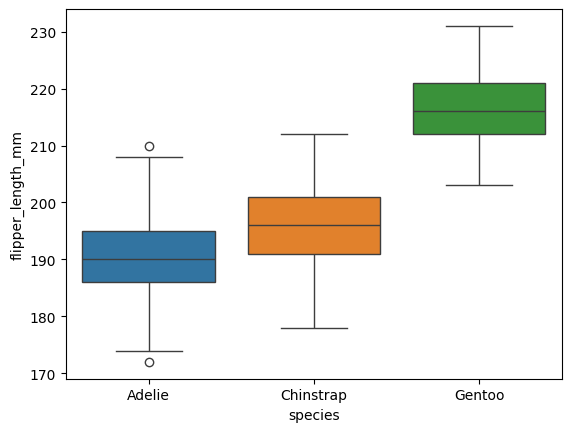

In [44]:
# YOUR CODE
fig, ax = plt.subplots(1,1)
sns.boxplot(data=df,x='species',y='flipper_length_mm',hue='species',ax=ax)



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


<Axes: xlabel='body_mass_g', ylabel='Density'>

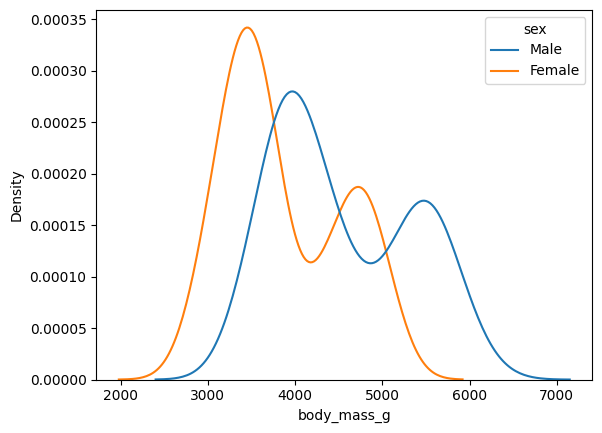

In [45]:
# YOUR CODE
sns.kdeplot(data=df,x='body_mass_g',hue='sex')



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



<Axes: xlabel='body_mass_g', ylabel='Proportion'>

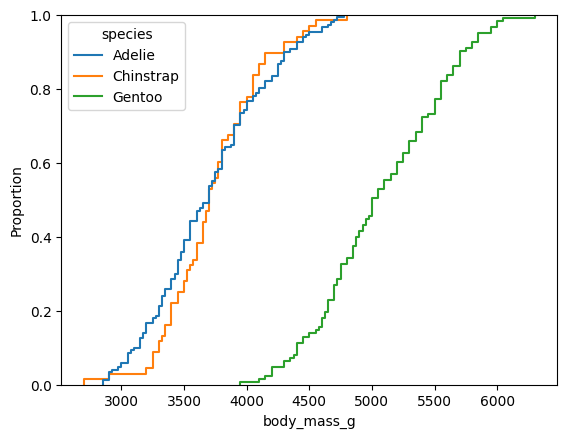

In [46]:
# YOUR CODE
sns.ecdfplot(data=df,x='body_mass_g',hue='species',)

**C3 Interpretation:**

Gentoo penguins are clearly the heaviest — their curve is shifted far to the right, with ~80% weighing less than 5500g and ~20% exceeding that. Adelie and Chinstrap have very similar weight distributions, with their curves nearly overlapping, and about 50% of Chinstrap penguins weigh less than ~3750g.


**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

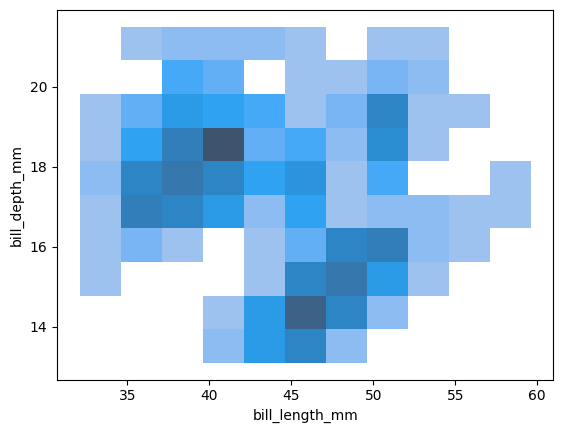

In [49]:

# YOUR CODE
sns.histplot(data=df,x='bill_length_mm',y='bill_depth_mm')

**C4 Interpretation:**

The color intensity represents the count of penguins in each 2D bin. Darker areas have more penguins with that combination of bill length and depth, while lighter areas have fewer. For example, penguins with bill length around 40-42.5mm and bill depth around 18-19mm are the most common in this dataset.

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

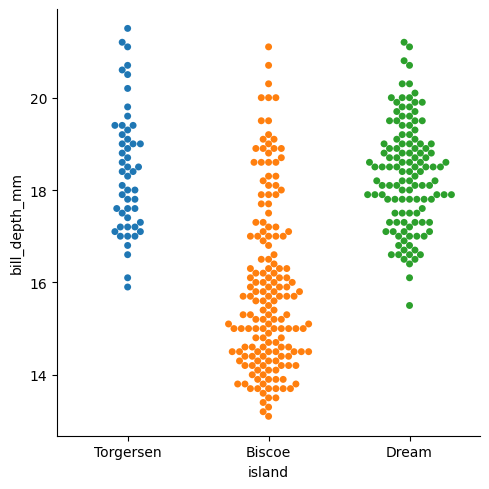

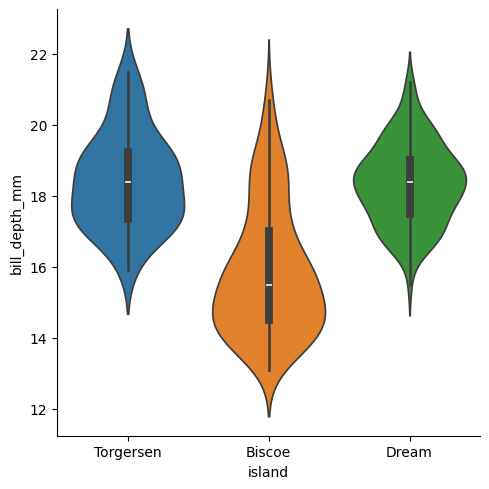

In [66]:
# YOUR CODE
sns.catplot(data=df,x='island',y='bill_depth_mm',hue='island',kind='swarm')
sns.catplot(data=df,x='island',y='bill_depth_mm',hue='island',kind='violin')

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

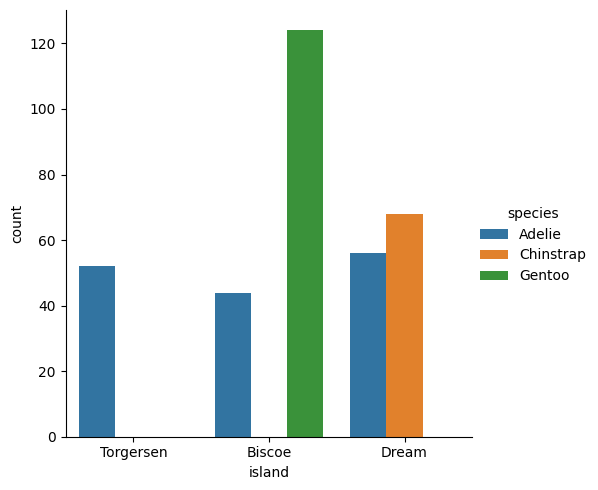

In [59]:
# YOUR CODE
sns.catplot(data=df,x='island',hue='species',kind='count')

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

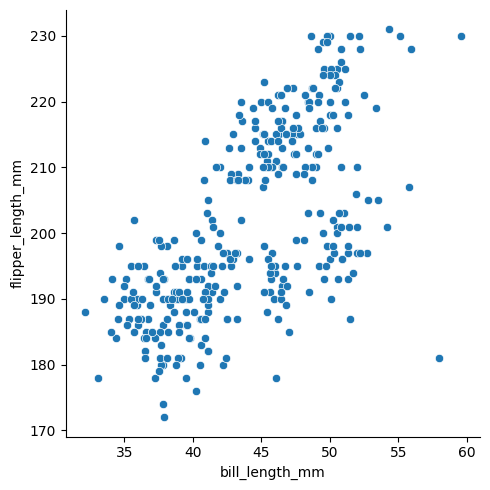

In [62]:
# YOUR CODE
sns.relplot(data=df,x='bill_length_mm',y='flipper_length_mm')

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

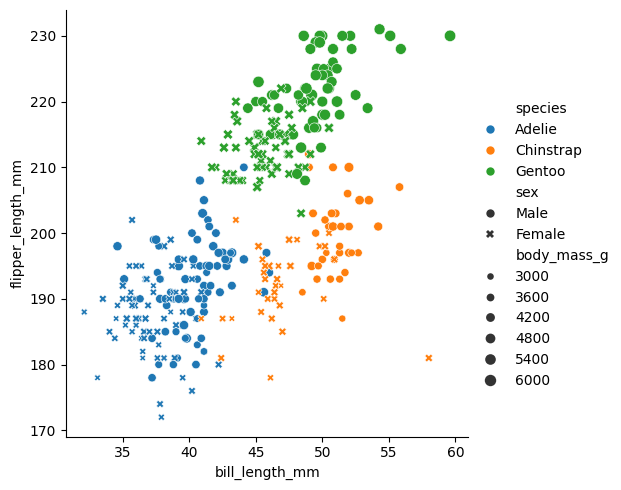

In [65]:
# YOUR CODE
sns.relplot(data=df,x='bill_length_mm',y='flipper_length_mm',hue='species',style='sex',size='body_mass_g')

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
